# **EDA - Exploratory Data Analysis**

* Análise do Significado das Variáveis do Dataset.
* Análise dos Tipos de Campos.
* Estatística Descritiva dos Campos (numéricos e categóricos).
* Análise Univariada.
* Análise Bivariada.
* Análise Multivariada.
* Verificação de Valores Ausentes (Missing).
* Verificação de Outliers (Valores Extremos).

### **Pré-Processamento dos Dados**

* 1º Corrigir os Valores Ausentes (missing): Imputação, Eliminação.
* 2º Identificar ou Remover Valores Ausentes (outliers).
* 3º Criação de Variáveis: Concatenação, junção de dados.
* 4º OneHotEncoding e LabelEncoding.
* 5º Escalonar os Dados ( Normalização, Padronização, Binarização ).
* 6º Seleção de Variáveis ( escolha das variáveis explicativas ).
* 7º Amostragem dos Dados: TrainTestSplit (treino, teste e validação).
* 8º Balanceamento de Classe (Smote).

In [1]:
import pandas as pd
import numpy as np

In [11]:
dados = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False)
dados.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


## **1º Corrigir os Valores Ausentes**

In [10]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(2), object(7)
memory usage: 142.5+ MB


In [12]:
dados['Global_active_power'] = pd.to_numeric(dados['Global_active_power'], errors='coerce')
dados['Global_reactive_power'] = pd.to_numeric(dados['Global_reactive_power'], errors='coerce')
dados['Voltage'] = pd.to_numeric(dados['Voltage'], errors='coerce')
dados['Global_intensity'] = pd.to_numeric(dados['Global_intensity'], errors='coerce')
dados['Sub_metering_1'] = pd.to_numeric(dados['Sub_metering_1'], errors='coerce')
dados['Sub_metering_2'] = pd.to_numeric(dados['Sub_metering_2'], errors='coerce')

In [ ]:
dados.info()

In [ ]:
# Checando onde há valores missing (nulos)
dados.isnull().sum()

In [ ]:
dados.isnull().values.any()

True

### **Eliminando Dados Faltantes**

In [17]:
# Remover as Duas primeiras Colunas (não dizem nada) e remover os valores nulos das demais
dados = dados.iloc[0:, 2:9].dropna()
dados.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [18]:
# Checando se ainda há valores missing
if dados.isnull().values.any():
    print(dados.isnull().sum())

### **Substituindo Dados Faltantes**

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = dados.drop(columns=['Voltage'], axis=1)
y = dados['Voltage']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.30, random_state=0)

impute = SimpleImputer(strategy='mean') # -> default
Xtrain_imputer = impute.fit_transform(Xtrain)

# IMPORTANTE -> Aqui passamos somente o trasform.
Xtest_imputer  = impute.transform(Xtest)

## **Detecção de Fraudes em Cartão de Crédito**

**1.Problema de Negócio**
* 492 fraudes e 284.807 transações. 
* Conjunto de dados altamente desbalanceado.
* Contém apenas variáveis de entrada numéricas, resultado de uma **PCA** **V1, V2..V28** são os componentes principais, os únicos recursos que não foram transformados com o **PCA** são **"Tempo"** e **"Qualidade"**.
* O recurso **"Classe"** é a **variável de resposta** e assume o valor 1 em caso de fraude e 0 em caso contrário.

**2.Análise Exploratória dos Dados**

In [43]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler # Padronização
from sklearn.preprocessing import MinMaxScaler   # Normalização
from sklearn.preprocessing import Normalizer     # Normalização

In [41]:
# Lendo os Dados
dados = pd.read_csv('creditcard.csv')

In [ ]:
# Informações dos Atributos
dados.info()

In [4]:
# Visualizando algumas linhas
dados.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Verificando Valores Missing
dados.isnull().sum()

In [6]:
# Dando uma Olhada na variável target
dados['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

In [ ]:
sns.countplot(dados['Class'])

In [ ]:
# Explorando as Correlações apenas com o target
dados.corr()['Class'].sort_values(ascending=False)

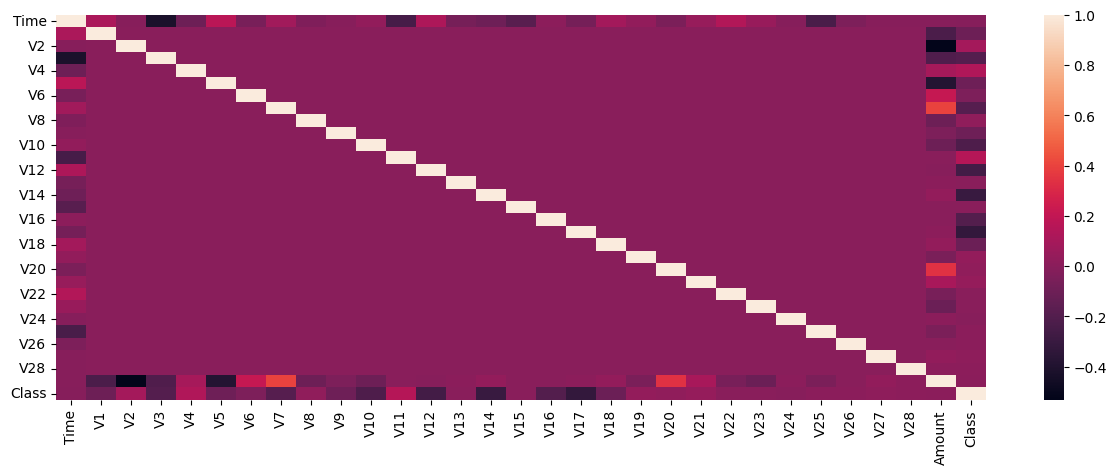

In [ ]:
# Ver a correlação entre todas as variáveis para se evitar Multicolineridade
corr = dados.corr()
plt.figure(figsize=(15,5))
sns.heatmap(corr, annot=False)
plt.show()

In [14]:
# Estatística Descritiva
dados.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**3.Pré-Processamento dos Dados**

In [42]:
X = dados.drop(columns=['Class'], axis=1)
y = dados['Class']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.30, random_state=7)

**Normalização ou Padronização dos Dados**

**Normalizar**

X' = ( X - Xmin ) / ( Xmax - Xmin )

Valores São Normalizados entre ( 0, 1 )

**Padronizar**

X' = ( X - Xmédia ) / DesvPad

Média fica igual a 0 e o Desvio Padrão igual a 1

In [ ]:
# Padronização
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest  = scaler.transform(Xtest)

In [31]:
pd.DataFrame(Xtrain, columns=X.columns).head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,1.411019,-0.435923,0.947705,-0.829797,-0.836513,0.416756,-1.163921,0.945654,0.160938,-0.202565,...,-0.041908,0.374235,1.238989,-0.245495,0.034782,-0.558881,0.175851,1.188130,0.968007,-0.354471
1,0.694958,1.093307,0.456880,-2.186984,0.453483,1.077000,-1.105395,0.728396,-0.429794,-0.069653,...,-0.086579,-0.108491,0.025329,-0.142305,0.537423,0.903790,1.439647,-0.192758,-0.044470,-0.363769
2,0.919353,-0.227239,0.142291,0.005292,-1.712374,0.237063,-0.992641,1.486746,-0.302872,0.787995,...,-0.087812,0.005428,-0.062721,0.381261,-0.110633,-0.645966,-3.160449,0.475380,0.684778,0.185245
3,-1.877710,-4.124544,4.301656,-0.730819,-0.614106,-1.000205,3.583327,-6.369973,-19.658166,2.784627,...,-6.104284,30.775686,-11.599185,5.619407,-0.869639,0.533899,0.428760,2.983264,0.597606,-0.344047
4,1.180749,-1.677665,-2.360541,-0.175538,0.599680,3.645452,-2.697129,-1.442309,0.141254,-0.213640,...,1.801323,1.088887,1.282737,1.237198,-0.670286,-0.414165,-0.341735,0.095765,1.011087,0.042519


**4.Criação da Máquina Preditiva**

In [36]:
# modelo = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2)

from xgboost import XGBClassifier
modelo = XGBClassifier()

modelo.fit(Xtrain, ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [37]:
ypred = modelo.predict(Xtest)

**5.Avaliando a Máquina Preditiva**

In [38]:
# Comparando Gabarito e Previsões da Máquina Preditiva
previsoes = pd.DataFrame({'Real':ytest, 'Pred':ypred})
previsoes.head()

,Real,Pred
86801,0,0
34867,0,0
151239,0,0
122560,0,0
77820,0,0


In [39]:
# Avaliação 
print('Classification metrics:\n', classification_report(ytest, ypred))

Classification metrics:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85288
           1       0.92      0.82      0.87       155

    accuracy                           1.00     85443
   macro avg       0.96      0.91      0.93     85443
weighted avg       1.00      1.00      1.00     85443



**Observações Importantes:**
* 1- Essas são as melhores métricas para se avaliar este modelo ? (AUC, ... ?).
* 2- Qual tratamento preciso fazer para lidar com **target** desbalanceado ?
* 3- Qual a melhor forma de se fazer a amostra dos dados ? (Cross Validation...).
* 4- Preciso Padronizar/Normalizar os Dados ( StandardScaler, Normalizer...).
* 5- Utilizo todas as Variáveis ? ( drop... ).
* 6- Qual o melhor modelo a ser utilizado (LGBM, Adaboost, XGBoost, ...).
* 7- Como avaliar o Overfitting ?